Abstract 

This test involves reducing noise in natural wildlife images. In order to achieve this, Gaussian noise will be added to a clean image to help simulate real world conditions. Then two different filters will be applied, a linear (mean) and a non-linear (median) filter. The performance of each method will be evaluated using quantitative metrics, PSNR and SSIM. These images will have visual comparisons on display including zoomed in regions to see the detail. The results provided by the images will highlight the differences between noise reduction and edge preservation, showcasing the advatanges and limitations of each.

Problem Statement 

Images captured in low-light environments tend to suffer from noise which reduces the clarity of the image. This is an issue when it comes to low-light photography, CCTV surveillance, and medical imaging, as detail is key. So this test will try to reduce noise while preserving the edges through the use of a linear (mean) filter and non-linear (median) filter, the effectiveness of how these methods preserve detail while balancing noise suppression will be evaluated to determine which method is the best for tackling noise.

Code

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

def my_spatial_filter(I, filter_type='mean', mask_size=5):
    if I.ndim == 3:
        I = np.mean(I, -1)  # convert to grayscale

    # Padding
    pad_size = mask_size // 2
    I_padded = np.pad(I, ((pad_size, pad_size), (pad_size, pad_size)), mode='constant')

    # Output image
    I2 = np.zeros_like(I_padded)

    # Apply selected filter
    for i in range(pad_size, I_padded.shape[0]-pad_size):
        for j in range(pad_size, I_padded.shape[1]-pad_size):
            pixbuffer = I_padded[i-pad_size:i+pad_size+1, j-pad_size:j+pad_size+1]
            if filter_type == 'mean':
                I2[i,j] = np.mean(pixbuffer)
            elif filter_type == 'median':
                I2[i,j] = np.median(pixbuffer)
            else:
                raise ValueError(f"Unknown filter type: {filter_type}")

    # Extract valid region
    filtered_image = I2[pad_size:-pad_size, pad_size:-pad_size]
    return filtered_image

def mean_squared_error(I, K):
    mse = np.mean((I - K) ** 2)
    return mse

def PSNR(I, K):
    mse = mean_squared_error(I, K)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

def SSIM(img1, img2):
    C1 = (0.01 * 1.0) ** 2
    C2 = (0.03 * 1.0) ** 2

    mu1 = np.mean(img1)
    mu2 = np.mean(img2)
    sigma1 = np.var(img1)
    sigma2 = np.var(img2)
    sigma12 = np.cov(img1.flatten(), img2.flatten())[0][1]
    numerator = (2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)
    denominator = (mu1**2 + mu2**2 + C1) * (np.var(img1) + np.var(img2) + C2)
    ssim_val = numerator / denominator
    return ssim_val
                            
# Use of Ai, ChatGPT (GPT-5 Mini.) prompt: "Loop through all images in a folder in Python and apply my existing image processing function to each one."
image_folder = r"C:\Users\igash\Documents\GitHub\DIG5125-Image-Video-Processing\Data\Images"
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg'))]

for image_file in image_files:
    filepath = os.path.join(image_folder, image_file)
    original = plt.imread(filepath)
    if original.ndim == 3:
        original = np.mean(original, -1)

    # Use of Ai, ChatGPT (GPT-5 Mini.) prompt: "Generate a noisy version of an image using Gaussian noise."
    # Add Gaussian noise 
    sigma = 25
    noisy_image = original + np.random.normal(0, sigma, original.shape)
    noisy_image = np.clip(noisy_image, 0, 255)
    

Image Convolution (Gaussian Blur)/Linear Filter (Mean)

In [8]:

mean_filtered = my_spatial_filter(noisy_image, filter_type='mean')

original_norm = original.astype(np.float32) / 255.0
noisy_image_norm = noisy_image.astype(np.float32) / 255.0
mean_filtered_norm = mean_filtered.astype(np.float32) / 255.0

# Quantitative metrics for mean filter
mse_mean = mean_squared_error(original_norm, mean_filtered_norm)
psnr_mean = PSNR(original_norm, mean_filtered_norm)
ssim_mean = SSIM(original_norm, mean_filtered_norm)

print(f"Image: {image_file} (Linear Filter)")
print("MSE (Mean Filter):", mse_mean)
print("PSNR (Mean Filter):", psnr_mean)
print("SSIM (Mean Filter):", ssim_mean)

Image: wolf.jpg (Linear Filter)
MSE (Mean Filter): 0.0035423923
PSNR (Mean Filter): 24.507034
SSIM (Mean Filter): 0.9904271593686971


Non-Linear Filter (Median)


In [9]:
median_filtered = my_spatial_filter(noisy_image, filter_type='median')
median_filtered_norm = median_filtered.astype(np.float32) / 255.0

# Quantitative metrics for median filter
mse_median = mean_squared_error(original_norm, median_filtered_norm)
psnr_median = PSNR(original_norm, median_filtered_norm)
ssim_median = SSIM(original_norm, median_filtered_norm)

print(f"Image: {image_file} (Non-Linear Filter)")
print("MSE (Median Filter):", mse_median)
print("PSNR (Median Filter):", psnr_median)
print("SSIM (Median Filter):", ssim_median)

Image: wolf.jpg (Non-Linear Filter)
MSE (Median Filter): 0.0016766767
PSNR (Median Filter): 27.755507
SSIM (Median Filter): 0.9957238762253849


Visualisation

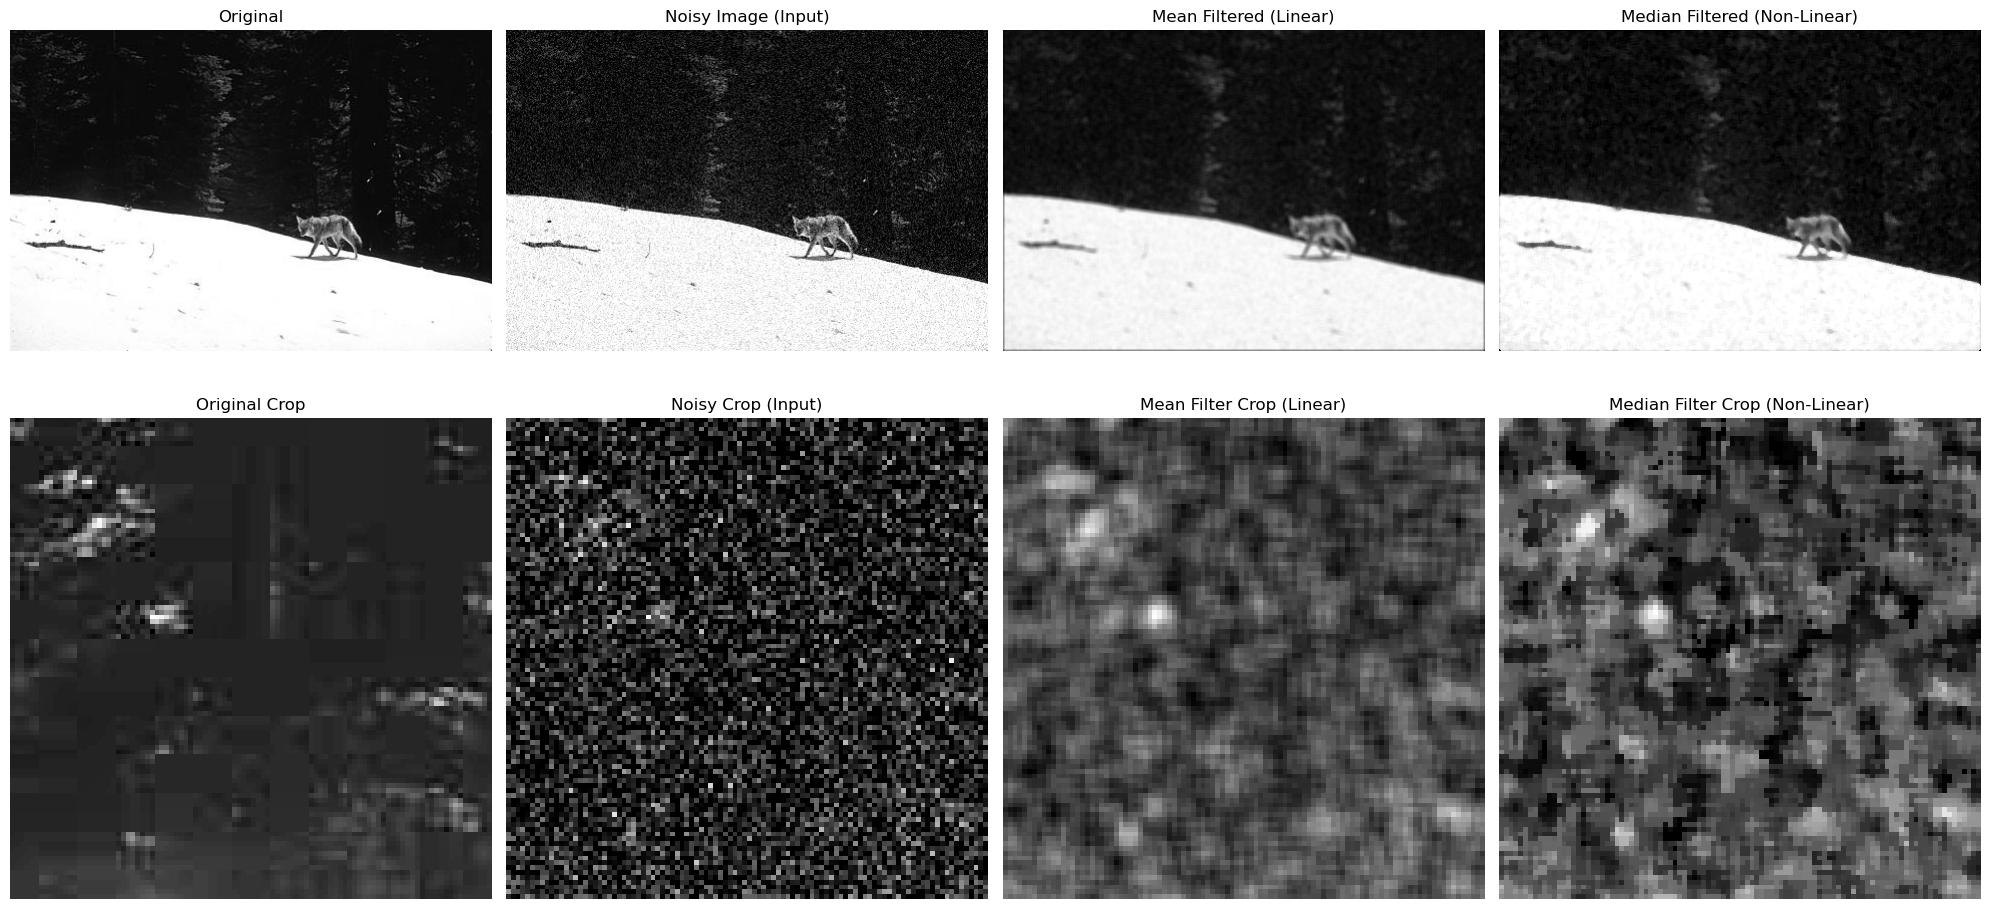

In [10]:
# Visualisation: original, noisy, filtered + zoom crop
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) 
axes = axes.ravel() 

# Zoom region parameters
x, y, w, h = 50, 50, 100, 100

# Original image
axes[0].imshow(original, cmap='gray')
axes[0].set_title("Original")

# Noisy image
axes[1].imshow(noisy_image, cmap='gray')
axes[1].set_title("Noisy Image (Input)")

# Mean Filtered image
axes[2].imshow(mean_filtered, cmap='gray')
axes[2].set_title("Mean Filtered (Linear)")

# Median Filtered image 
axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title("Median Filtered (Non-Linear)")

# Original Crop 
axes[4].imshow(original[y:y+h, x:x+w], cmap='gray')
axes[4].set_title("Original Crop")

# Noisy crop 
axes[5].imshow(noisy_image[y:y+h, x:x+w], cmap='gray')
axes[5].set_title("Noisy Crop (Input)")

# Mean Filter crop 
axes[6].imshow(mean_filtered[y:y+h, x:x+w], cmap='gray')
axes[6].set_title("Mean Filter Crop (Linear)")

# Median Filter crop 
axes[7].imshow(median_filtered[y:y+h, x:x+w], cmap='gray')
axes[7].set_title("Median Filter Crop (Non-Linear)")

# Hides axis ticks/labels so it looks cleaner
for ax in axes:
    ax.axis('off')
    
plt.tight_layout()
plt.show()

Performance analysis:
To analyse the performance of the filtering method a number of performance metrics were introduced. These were used to compare an image with a controlled amount of noise that has been filtered using a chosen method and compared against a ground truth.

The reason the images are converted to greyscale is because, PSNR, SSIM, and spatial filters such as mean and median are designed for single-channel images, if they were coloured images then the metrics would have to compute for each channel being R, G, and B. Colour isn't relevant here as noise supression and edge preservation are instead. Using greyscale keeps things simple, consistent, and necessary.


Function: add_noise
This is a function for adding a controlled amount of normally distributed noise to an image. This allows us to control the amount of noise in an image prior to denoising.

Function: my_spatial_filter
This function applies a mean or median filter to an image. This enables a direct comparison between the two filtering methods.

Linear VS Non-Linear Operators

The mean filter being a linear method, reduces noise by averaging pixel values, this means it can be effective for Gaussian noise, however edges and details can be lost due to blurring, the smoothing happens because the noise and edges are treated similary within the process.

The median filter being a non-linear method, replaces pixels with the median value instead of averaging the values, enabling it to not only suppress noise but preserve edges more effectively but it can distort thinner structures.

Other operators such as bilateral filtering which is also a non-linear method, can have improved edge preservation thanks to using intensity similarity.


Mean squared error:
$${\displaystyle \operatorname {MSE} ={\frac {1}{n}}\sum _{i=1}^{n}\left(Y_{i}-{\hat {Y_{i}}}\right)^{2}}$$

MSE measures the average squared difference between the original image and the processed one on a pixel by pixel level. Lower MSE values would indicate that the filtered image is closer to the original, therefore less errors in the noise reduction process.

Peak Signal-to-Noise Ratio (PSNR):
$$\operatorname{PSNR} = 10 \log_{10} \left( \frac{\operatorname{MAX}_I^2}{\operatorname{MSE}} \right)$$

PSNR measures how close a processed image is to the original one by comparing pixel errors overall. It derives from Mean squared error and uses decibels, higher PSNR indicates better image quality and less distortion thanks to any noise.

Structural Similarity Index (SSIM):
$$\operatorname{SSIM}(x, y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}$$

SSIM measures the similarity between two images, comparing the brightness and contrast rather than just pixels. It's moreso meant to reflect human perception rather than just metric errors. SSIM goes from -1 to 1, a value that is closer to 1 indicates a higher similarity to the original image meaning edges and textures are more effectively preserved.


Quantitative Results

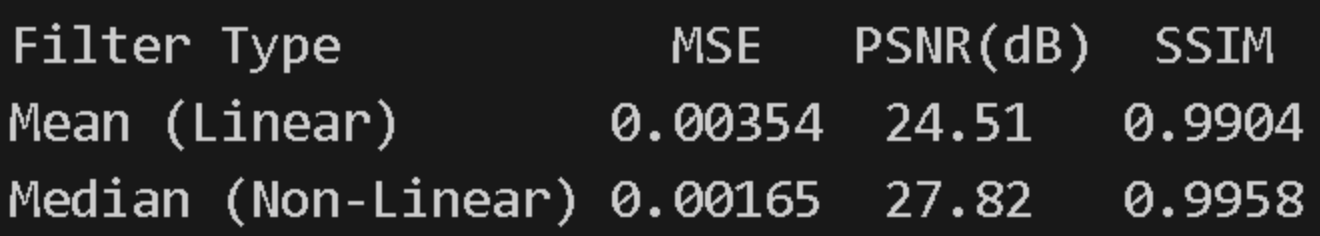

The median filter achieved higher PSNR and SSIM values than the mean filter, indicating better noise supression and more effective preservation of image structure and edges. This is supported by the lower mean squared error it has compared to the mean, showing that the median filter uses less distortion when it comes to the original image.

Quantitative Limitations

Because PSNR and MSE measure differences on a pixel level, it assumes these miniscule errors translate to human perception accurately which may not be the case as edges can still be blurred while producing a high PSNR value

SSIM is more accurate in this process of translating to human perception as it uses extra structural information such as brightness and contrast but it will still lack the neccessary effectiveness when it comes to this concept, just to a lesser extent.

Qualitative Results

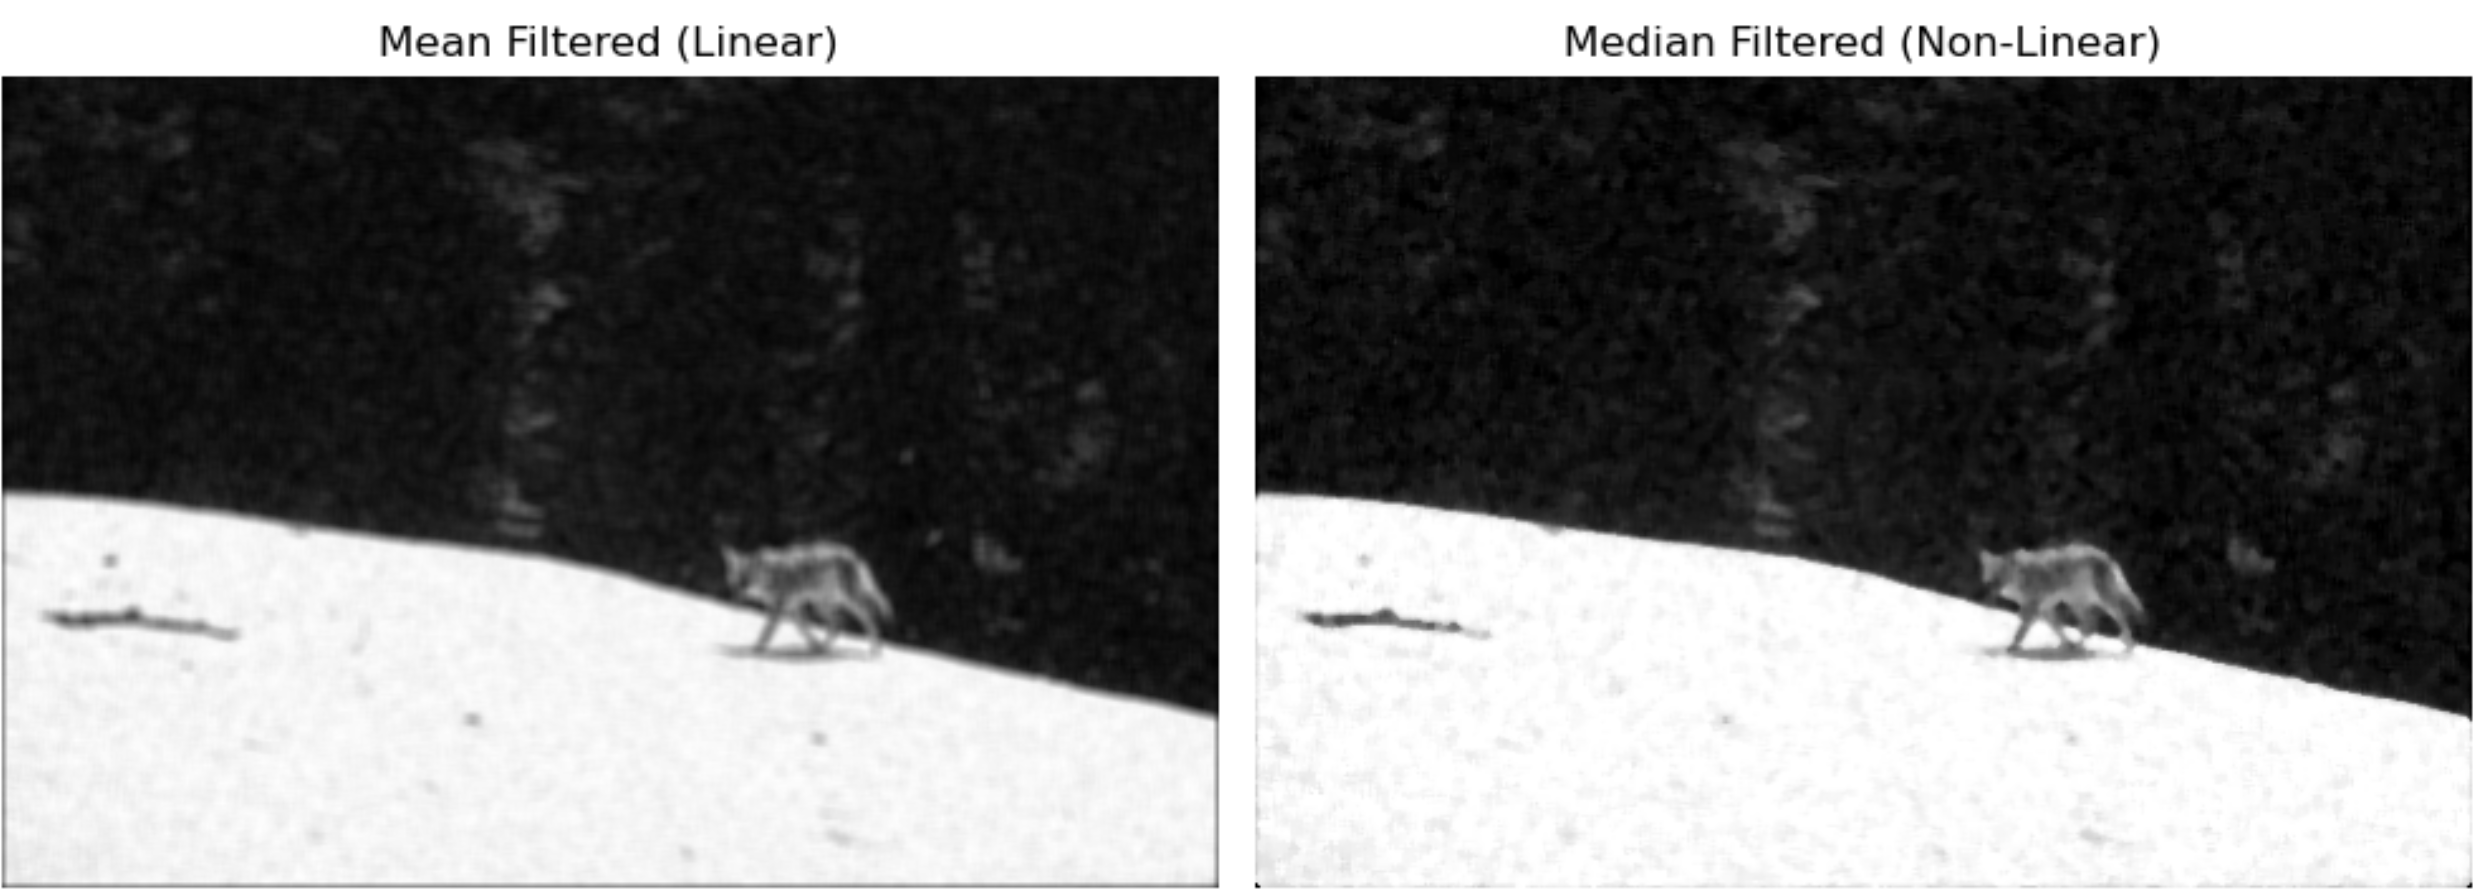 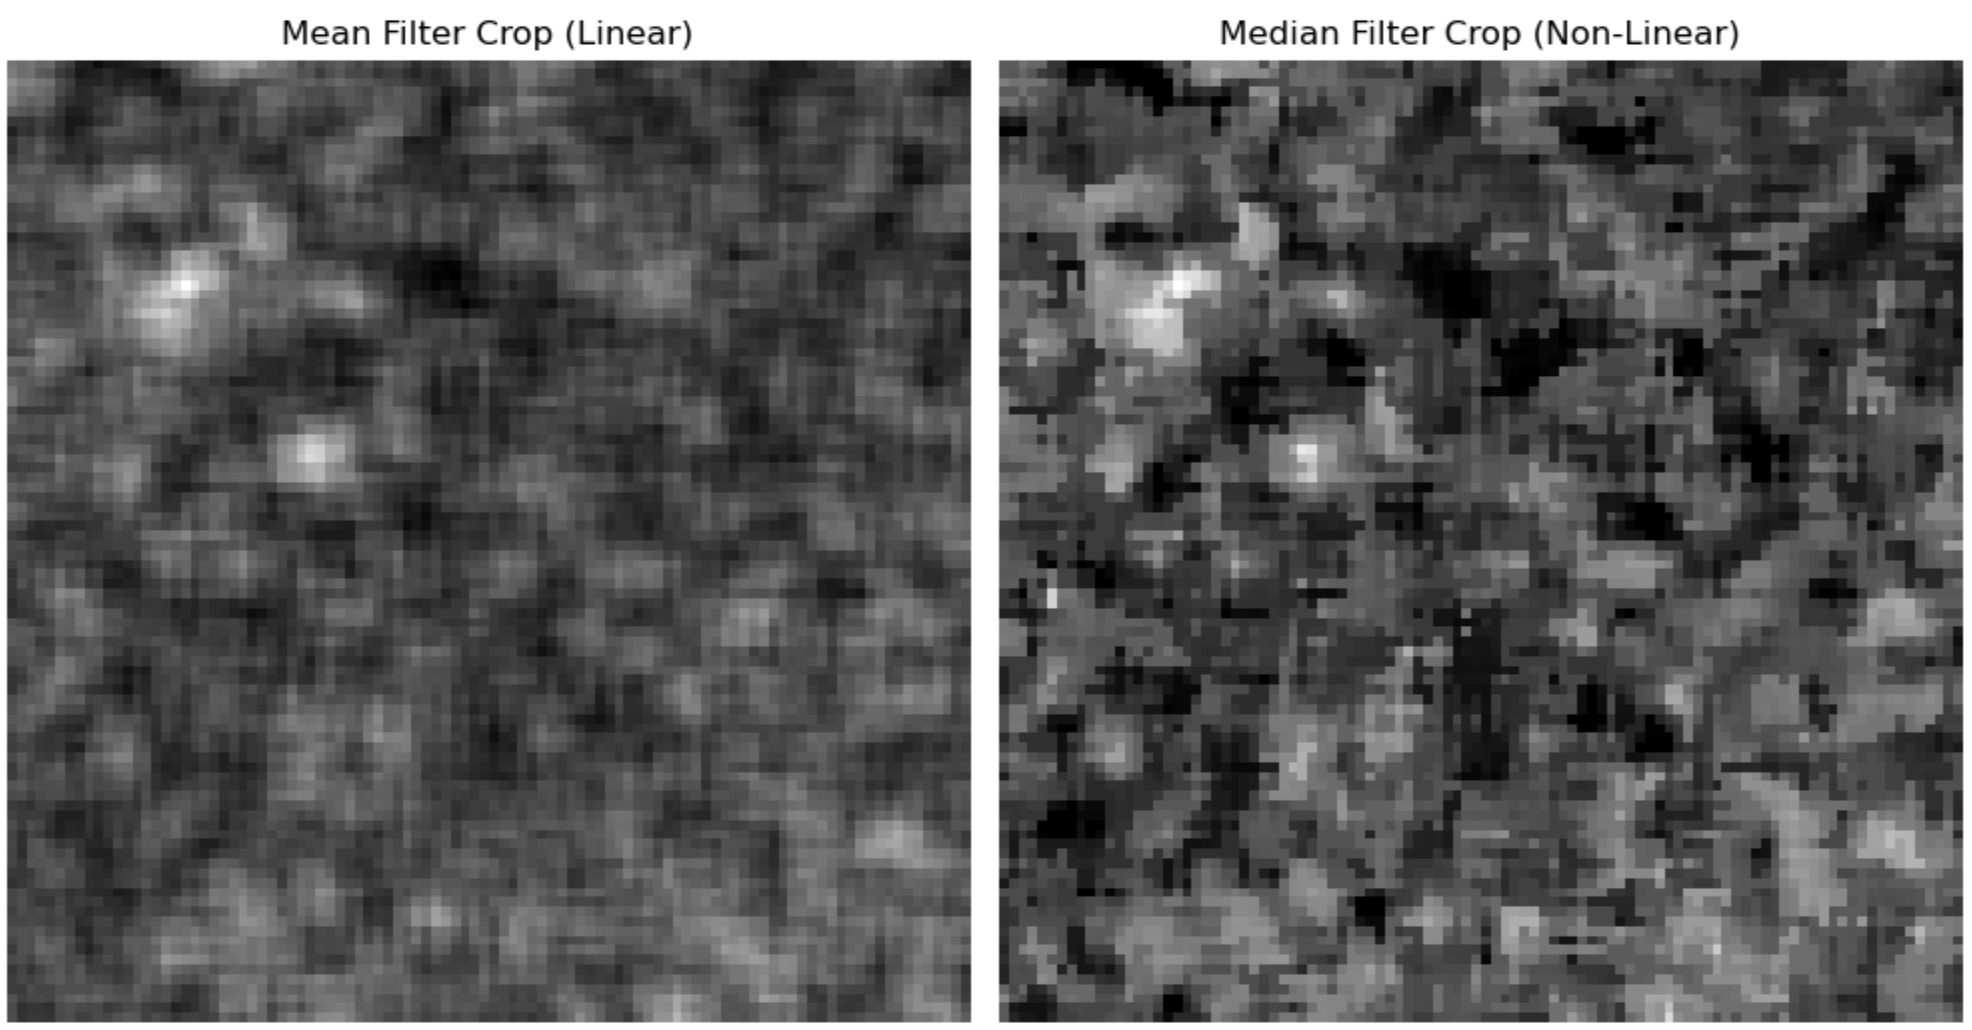

You can clearly see that the Median has more clarity and less noise compared the mean, the mean looks more blurry and theres more smoothing over when it comes to the edges like they almost blend together, it almost gives a whitewash look to an extent as it fades the colour and this can be seen in the crops for both images, the median preserving the blacks while the mean just looks grey. There's not only a loss in detail but a loss in clarity and colour, and overall weaker visualisation when it comes to the mean whereas the median preserves detail, has a higher clarity, preserves colour, and just looks cleaner and sharper without having as much grain you'd get from the noise.

Qualitative Limitations 

Different people may view the images in different ways due to varying perception, eyesight, or display settings on different devices including differing monitor sizes, so edge blurring for instance may not be noticeable at first or at all and finer details can be missed which is why the crops are useful and can help solve this issue just in case.


Journal References:

Gonzalez, R. C., & Woods, R. E. Digital Image Processing. Pearson.
- Discusses Mean filter (linear convolution), and Median filter (non-linear order statistic filter)

Wang, Z., Bovik, A. C., Sheikh, H. R., & Simoncelli, E. P. (2004). Image quality assessment: From error visibility to structural similarity. IEEE Transactions on Image Processing.
- Justifies the use of SSIM and structural comparison.

Jain, A. K. (1989). Fundamentals of Digital Image Processing
- Discusses Gaussian noise modelling and Synthetic noise experiments.